In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Shape: (200, 5)

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


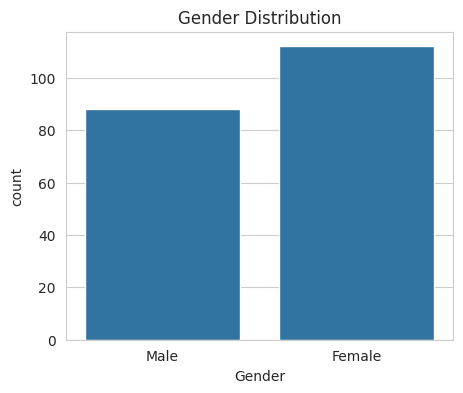

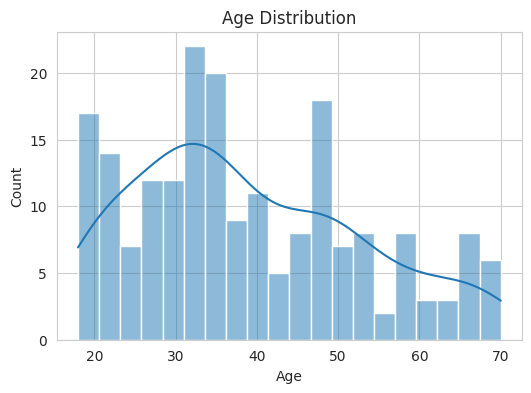

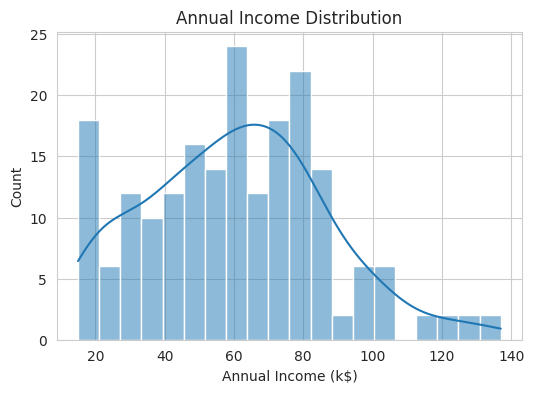

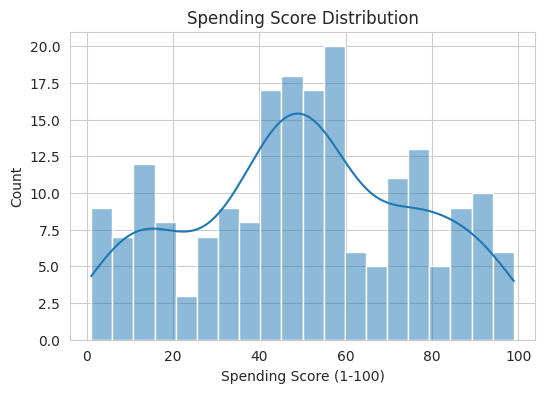

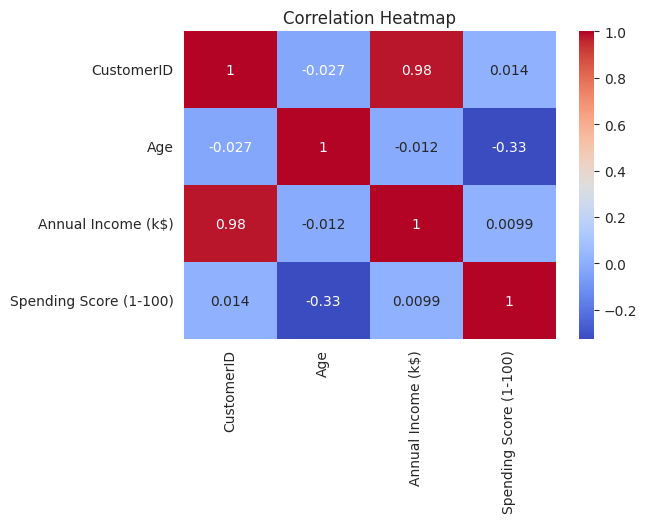

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Gender Distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Annual Income Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

# Spending Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Observation

- Dataset contains 200 customers.
- No missing values were found.
- Male and Female customers are almost equally distributed.
- Most customers belong to the young and middle-age groups.
- Annual income and spending score vary significantly.
- Correlation between variables is weak, indicating clustering is suitable.

In [7]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


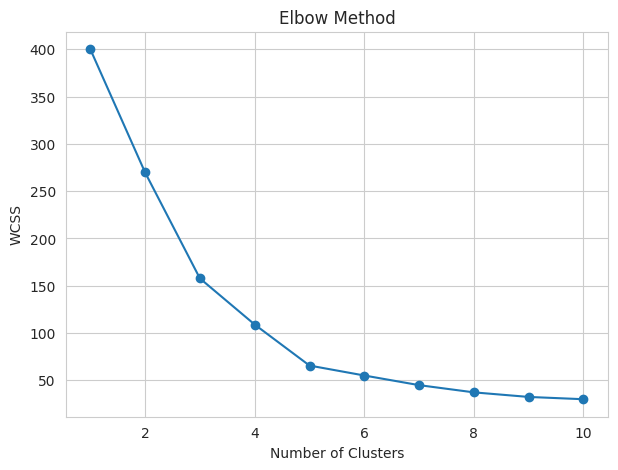

In [8]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [9]:
from sklearn.cluster import KMeans

# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Predict cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Display first few rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


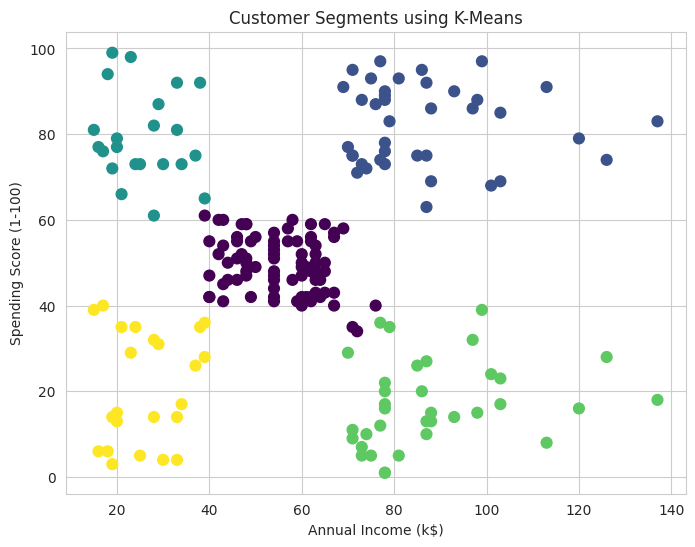

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")

plt.show()

In [11]:
cluster_summary = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


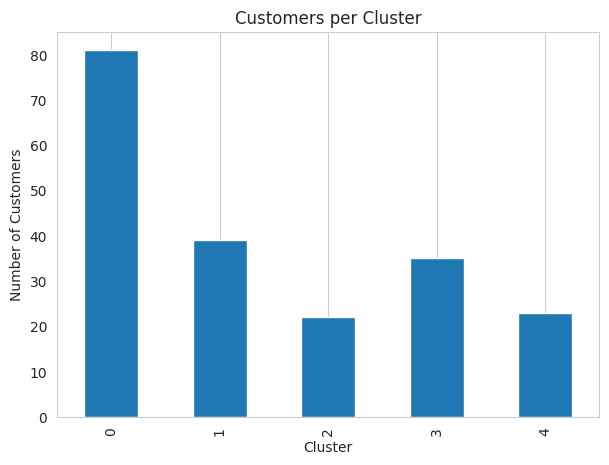

In [12]:
plt.figure(figsize=(7,5))
df["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y")
plt.show()

# Customer Segment Insights

## Cluster Analysis

- **Cluster 0:** Medium income and medium spending customers. These customers have balanced purchasing behavior and contribute to regular sales.

- **Cluster 1:** High income but low spending customers. They have strong purchasing power but currently spend less, making them ideal targets for personalized offers and discounts.

- **Cluster 2:** Low income but high spending customers. Despite having lower income, they spend actively and respond well to attractive promotions.

- **Cluster 3:** High income and high spending customers. These are premium customers who contribute significantly to revenue and should be rewarded with loyalty programs and exclusive benefits.

- **Cluster 4:** Low income and low spending customers. These customers contribute less to sales and can be encouraged through budget-friendly marketing campaigns.

# Conclusion

This project successfully segmented customers into **five distinct groups** using the K-Means clustering algorithm based on Annual Income and Spending Score.

The Elbow Method was used to determine the optimal number of clusters (K = 5). Customer segmentation helps businesses better understand customer behavior and design targeted marketing strategies.

### Business Recommendations

- Reward premium customers with loyalty programs and exclusive offers.
- Encourage high-income, low-spending customers through personalized promotions.
- Maintain engagement with medium-income customers using seasonal offers.
- Target low-income, high-spending customers with attractive discounts.
- Use customer segmentation to improve marketing efficiency, customer satisfaction, and overall business growth.